## Nome:Mayara Cristina
## Matrícula:574

---

# Atividade 10 - Integradora

Uma equipe de engenharia está analisando o sistema de resfriamento de um reator químico acoplado a uma malha de tubulação.

O trabalho tem **duas etapas conectadas**:

1. **Etapa 1 — Sistemas Lineares:** a temperatura em regime permanente de 3 nós de junção da malha de tubulação é modelada por um sistema linear $A\cdot x = b$, resolvido pelo **Método de Gauss-Seidel**.
2. **Etapa 2 — Ajuste Não Linear:** a evolução da temperatura de um desses nós **ao longo do tempo**, durante o resfriamento transiente, segue um comportamento não linear (exponencial amortecido com componente oscilatória), ajustado pelo **Método de Gauss-Newton**.

**A conexão entre as duas etapas:** o método de Gauss-Newton, usado na Etapa 2, precisa resolver um sistema linear a cada iteração:

$$ (J^T J)\,\Delta = -J^T r $$

Nas atividades anteriores esse sistema era resolvido com `np.linalg.solve` (método direto). Nesta atividade, você vai **resolver esse sistema usando a sua própria implementação do Gauss-Seidel** (Etapa 1), integrando os dois métodos estudados.

---

## Personalização por Matrícula

**Todo o sistema linear da Etapa 1 e a estimativa inicial da Etapa 2 dependem da sua matrícula**.

Extraia três dígitos da sua matrícula da seguinte forma:

$$d_1 = matrícula \%  5 \qquad d_2 = \left\lfloor \dfrac{matrícula}{10} \right\rfloor \% 5 \qquad d_3 = \left\lfloor \dfrac{matrícula}{100} \right\rfloor \% 5$$

Esses valores serão usados para:
- Ajustar o vetor $b$ do sistema linear da Etapa 1.
- Ajustar a estimativa inicial $p_0$ do ajuste não linear da Etapa 2.

**Implemente a célula abaixo com a sua matrícula.** Todo o restante da atividade depende deste valor.

**Importante: Use/adapte as funções de atividades anteriores. Implementações diferentes serão desconsideradas.**

In [2]:
# TODO: substitua pelo valor da sua matrícula
matricula = 574  # <-- coloque aqui sua matrícula

d1 = matricula % 5
d2 = (matricula // 10) % 5
d3 = (matricula // 100) % 5

print(f"Matrícula: {matricula}")
print(f"d1 = {d1}  |  d2 = {d2}  |  d3 = {d3}")

Matrícula: 574
d1 = 4  |  d2 = 2  |  d3 = 0


---

# Etapa 1 — Sistema Linear e Método de Gauss-Seidel

A malha de tubulação possui 3 nós de interesse ($T_1$, $T_2$, $T_3$). O balanço térmico resultou no sistema:

$$10T_1 - T_2 + 2T_3 = 6 + d_1$$
$$-T_1 + 11T_2 - T_3 = 25 + d_2$$
$$2T_1 - T_2 + 10T_3 = -11 + d_3$$

onde $d_1$, $d_2$, $d_3$ são os valores calculados a partir da sua matrícula.

In [3]:
from IPython.display import display

# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

### Parte 1.1 — Montagem do Sistema Personalizado

Monte a matriz `A` e o vetor `b` usando `d1`, `d2`, `d3` calculados a partir da sua matrícula. Exiba a tabela de coeficientes.

In [4]:
A = np.array([
    [10, -1, 2],
    [-1, 11, -1],
    [2, -1, 10]
], dtype=float)

b = np.array([
    6 + d1,
    25 + d2,
    -11 + d3
], dtype=float)

tabela_coeficientes = pd.DataFrame(
    A,
    columns=["T1", "T2", "T3"],
    index=["Equação 1", "Equação 2", "Equação 3"]
)

tabela_coeficientes["b"] = b

display(tabela_coeficientes)

,T1,T2,T3,b
Equação 1,10.0,-1.0,2.0,10.0
Equação 2,-1.0,11.0,-1.0,27.0
Equação 3,2.0,-1.0,10.0,-11.0


### Parte 1.2 — Verificação da Convergência (Dominância Diagonal)

Verifique se a matriz `A` do seu sistema personalizado é estritamente diagonalmente dominante, usando a função `eh_diagonalmente_dominante`.

In [5]:
def eh_diagonalmente_dominante(A):
    for i in range(len(A)):
        diagonal = abs(A[i, i])
        soma_outros = np.sum(np.abs(A[i])) - diagonal

        if diagonal <= soma_outros:
            return False

    return True


print(
    "A matriz é estritamente diagonalmente dominante?",
    eh_diagonalmente_dominante(A)
)

A matriz é estritamente diagonalmente dominante? True


**Formulário — Critério de Dominância Diagonal**

$$|a_{ii}| > \sum_{\substack{j=1 \\ j \neq i}}^{n} |a_{ij}|$$

### Parte 1.3 — Resolução pelo Método de Gauss-Seidel

Resolva o sistema com:
- Estimativa inicial: $x^{(0)} = [0, 0, 0]$
- Tolerância: $\varepsilon = 10^{-4}$
- Número máximo de iterações: $50$

In [6]:
def gauss_seidel(A, b, x0, tol=1e-4, max_iter=50):
    x = np.array(x0, dtype=float).copy()
    historico = []

    for k in range(max_iter):
        x_anterior = x.copy()

        for i in range(len(b)):
            soma_antes = np.dot(A[i, :i], x[:i])
            soma_depois = np.dot(A[i, i+1:], x_anterior[i+1:])

            x[i] = (b[i] - soma_antes - soma_depois) / A[i, i]

        erro = np.max(np.abs(x - x_anterior))
        historico.append([k + 1, *x.copy(), erro])

        if erro < tol:
            break

    return x, historico


x0 = [0, 0, 0]

solucao, historico = gauss_seidel(
    A, b, x0, tol=1e-4, max_iter=50
)

print(f"T1 = {solucao[0]:.6f}")
print(f"T2 = {solucao[1]:.6f}")
print(f"T3 = {solucao[2]:.6f}")
print(f"Número de iterações: {len(historico)}")

T1 = 1.477886
T2 = 2.484615
T3 = -1.147116
Número de iterações: 5


**Formulário — Método de Gauss-Seidel**

$$x_i^{(k+1)} = \frac{1}{a_{ii}}\left(b_i - \sum_{j < i} a_{ij}\,x_j^{(k+1)} - \sum_{j > i} a_{ij}\,x_j^{(k)}\right)$$

**Critério de Parada:**

$$\max_i \left| x_i^{(k+1)} - x_i^{(k)} \right| < \varepsilon$$

### Parte 1.4 — Tabela de Iterações

Armazene os valores de $T_1$, $T_2$, $T_3$ obtidos em cada iteração em um DataFrame.

In [7]:
tabela_iteracoes = pd.DataFrame(
    historico,
    columns=["Iteração", "T1", "T2", "T3", "Erro"]
)

display(tabela_iteracoes)

,Iteração,T1,T2,T3,Erro
0,1,1.000000,2.545455,-1.045455,2.545455
1,2,1.463636,2.492562,-1.143471,0.463636
2,3,1.477950,2.484953,-1.147095,0.014314
3,4,1.477914,2.484620,-1.147121,0.000333
4,5,1.477886,2.484615,-1.147116,0.000028


### Parte 1.5 — Comparação com a Solução Exata

Resolva o mesmo sistema (personalizado) com `np.linalg.solve` e compare com o resultado do Gauss-Seidel (Erro Absoluto e Erro Percentual).

In [8]:
solucao_exata = np.linalg.solve(A, b)

erro_absoluto = np.abs(solucao - solucao_exata)
erro_percentual = (erro_absoluto / np.abs(solucao_exata)) * 100

tabela_comparacao = pd.DataFrame({
    "Temperatura": ["T1", "T2", "T3"],
    "Gauss-Seidel": solucao,
    "Solução direta": solucao_exata,
    "Erro Absoluto": erro_absoluto,
    "Erro Percentual (%)": erro_percentual
})

display(tabela_comparacao)


,Temperatura,Gauss-Seidel,Solução direta,Erro Absoluto,Erro Percentual (%)
0,T1,1.477886,1.477885,1.549549e-06,0.000105
1,T2,2.484615,2.484615,3.561039e-07,0.000014
2,T3,-1.147116,-1.147115,3.455203e-07,0.000030


### Parte 1.6 — Gráfico de Convergência

Use `plot_convergencia` para visualizar a evolução do erro entre iterações.

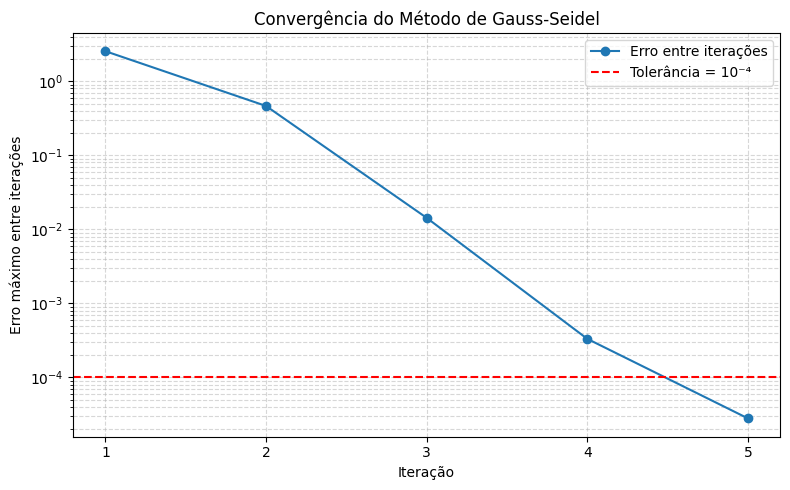

In [9]:
def plot_convergencia(historico):
    dados = np.array(historico)
    iteracoes = dados[:, 0]
    erros = dados[:, -1]

    plt.figure(figsize=(8, 5))
    plt.semilogy(iteracoes, erros, marker="o", label="Erro entre iterações")

    plt.axhline(
        y=1e-4,
        color="red",
        linestyle="--",
        label="Tolerância = 10⁻⁴"
    )

    plt.xlabel("Iteração")
    plt.ylabel("Erro máximo entre iterações")
    plt.title("Convergência do Método de Gauss-Seidel")
    plt.xticks(iteracoes)
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_convergencia(historico)

---

# Etapa 2 — Ajuste Não Linear (integrando o Gauss-Seidel)

Um dos nós da malha ($T_1$) foi monitorado ao longo do tempo durante um transiente de resfriamento. O comportamento não segue um polinômio simples, exigindo um modelo não linear ("função cabeluda"):

$$T(t) = T_{amb} + A \cdot e^{-a \cdot t} + B \cdot e^{-b \cdot t} \cdot \cos(w \cdot t)$$

Os dados coletados pelo sistema SCADA estão na tabela abaixo. **Antes de usar os dados, aplique a personalização pela matrícula**: some $\left(\dfrac{d_1 - 2}{2}\right)$ a todos os valores de temperatura medidos (pequeno deslocamento vertical, específico da sua matrícula).

In [10]:
ts = np.array([0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 7.0, 9.0, 12.0])
ys_base = np.array([820.0, 695.5, 580.2, 415.0, 310.8, 240.3, 192.1, 135.4, 102.7, 75.0])

# Personalização pela matrícula: pequeno deslocamento vertical
deslocamento = (d1 - 2) / 2
ys = ys_base + deslocamento

tabela_dados = pd.DataFrame({"t (min)": ts, "T medida (°C)": ys})
display(tabela_dados)

,t (min),T medida (°C)
0,0.0,821.0
1,0.5,696.5
2,1.0,581.2
3,2.0,416.0
4,3.0,311.8
5,4.0,241.3
6,5.0,193.1
7,7.0,136.4
8,9.0,103.7
9,12.0,76.0


In [11]:
# Modelo: Decaimento Exponencial Amortecido com Termo Senoidal Amortecido (fornecido)
def modelo_nao_linear(t, T_amb, A, a, B, b, w):
    return T_amb + A * np.exp(-a * t) + B * np.exp(-b * t) * np.cos(w * t)

### A integração: resolvendo o sistema normal com Gauss-Seidel

A função `ajustar_modelo` abaixo implementa o método de Gauss-Newton. A cada iteração, ela precisa resolver o sistema linear:

$$(J^T J)\,\Delta = -J^T r$$

O parâmetro `metodo_solver` controla **como** esse sistema é resolvido:
- `'direto'` → usa `np.linalg.solve` (como nas atividades anteriores).
- `'gauss_seidel'` → usa a **sua função `gauss_seidel`** implementada na Etapa 1.

Note que $(J^TJ)$ é sempre simétrica, mas **não necessariamente diagonalmente dominante** — isso é algo que você vai investigar na Parte Teórica.

In [12]:
def ajustar_modelo(t, y, params0, metodo_solver='direto', max_iter=200, tol=1e-8):
    """
    Ajusta o modelo não linear aos dados (t, y) pelo método de Gauss-Newton,
    partindo da estimativa inicial params0.

    Parâmetros:
    -----------
    t, y : array-like
        Dados medidos.
    params0 : array-like
        Estimativa inicial dos parâmetros (T_amb, A, a, B, b, w).
    metodo_solver : str
        'direto'        -> resolve (J^T J) delta = -J^T r com np.linalg.solve
        'gauss_seidel'  -> resolve (J^T J) delta = -J^T r com a função gauss_seidel (Etapa 1)
    max_iter, tol : parâmetros de parada do Gauss-Newton.

    Retorna:
    --------
    popt : array
        Parâmetros otimizados (T_amb, A, a, B, b, w).
    """
    def residuo(params):
        return modelo_nao_linear(t, *params) - y

    def jacobiano_numerico(params, eps=1e-6):
        n = len(params)
        r0 = residuo(params)
        J = np.zeros((len(t), n))
        for j in range(n):
            p_perturbado = params.copy()
            p_perturbado[j] += eps
            J[:, j] = (residuo(p_perturbado) - r0) / eps
        return J, r0

    params = np.array(params0, dtype=float)
    for _ in range(max_iter):
        J, r = jacobiano_numerico(params)
        JTJ = J.T @ J
        JTr = J.T @ r

        if metodo_solver == 'direto':
            delta = np.linalg.solve(JTJ, -JTr)
        elif metodo_solver == 'gauss_seidel':
            # TODO (Parte 2.1): chame aqui a sua função gauss_seidel da Etapa 1
            # para resolver JTJ . delta = -JTr, em vez de np.linalg.solve.
            # Dica: gauss_seidel retorna (solução, histórico) -> use apenas a solução.
            delta = None
        else:
            raise ValueError("metodo_solver deve ser 'direto' ou 'gauss_seidel'")

        alpha = 1.0
        erro_atual = np.sum(r**2)
        while True:
            novo_params = params + alpha * delta
            novo_erro = np.sum(residuo(novo_params)**2)
            if novo_erro < erro_atual or alpha < 1e-8:
                break
            alpha /= 2

        params = novo_params
        if np.linalg.norm(alpha * delta) < tol:
            break

    return params  # Saídas: T_amb, A, a, B, b, w

### Parte 2.1 — Completar a Integração

Complete o trecho `TODO` da função `ajustar_modelo` acima, chamando a sua função `gauss_seidel` para resolver o sistema normal quando `metodo_solver='gauss_seidel'`.

In [13]:
def ajustar_modelo(t, y, params0, metodo_solver='direto',
                   max_iter=200, tol=1e-8):
    """
    Ajusta o modelo pelo método de Gauss-Newton.

    Retorna os parâmetros: T_amb, A, a, B, b, w.
    """

    def residuo(params):
        return modelo_nao_linear(t, *params) - y

    def jacobiano_numerico(params, eps=1e-6):
        n = len(params)
        r0 = residuo(params)
        J = np.zeros((len(t), n))

        for j in range(n):
            p_perturbado = params.copy()
            p_perturbado[j] += eps

            J[:, j] = (residuo(p_perturbado) - r0) / eps

        return J, r0

    params = np.array(params0, dtype=float)

    for _ in range(max_iter):
        J, r = jacobiano_numerico(params)
        JTJ = J.T @ J
        JTr = J.T @ r

        if metodo_solver == 'direto':
            delta = np.linalg.solve(JTJ, -JTr)

        elif metodo_solver == 'gauss_seidel':
            delta, _ = gauss_seidel(
                JTJ,
                -JTr,
                x0=np.zeros(len(params)),
                tol=1e-10,
                max_iter=10000
            )

        else:
            raise ValueError(
                "metodo_solver deve ser 'direto' ou 'gauss_seidel'"
            )

        alpha = 1.0
        erro_atual = np.sum(r**2)

        while True:
            novo_params = params + alpha * delta
            novo_erro = np.sum(residuo(novo_params)**2)

            if novo_erro < erro_atual or alpha < 1e-8:
                break

            alpha /= 2

        params = novo_params

        if np.linalg.norm(alpha * delta) < tol:
            break

    return params

### Parte 2.2 — Estimativa Inicial Personalizada e Ajuste do Modelo

Use a estimativa inicial $p_0 = [25 + d_3,\ 600,\ 0.2,\ 200,\ 0.1,\ 1.5]$ e ajuste o modelo aos dados **usando `metodo_solver='gauss_seidel'`**.

Em seguida, estime a temperatura nos instantes $t = 1.5$ min, $t = 6.0$ min e $t = 10.0$ min (arredonde para duas casas decimais).

In [14]:
# Estimativa inicial personalizada pela matrícula
p0 = [25 + d3, 600, 0.2, 200, 0.1, 1.5]

# Ajuste usando Gauss-Seidel
popt_gs = ajustar_modelo(
    ts,
    ys,
    p0,
    metodo_solver='gauss_seidel'
)

# Exibir os parâmetros encontrados
tabela_parametros = pd.DataFrame({
    "Parâmetro": ["T_amb", "A", "a", "B", "b", "w"],
    "Valor ajustado": popt_gs
})

display(tabela_parametros)

# Estimar as temperaturas nos instantes solicitados
tempos_estimados = np.array([1.5, 6.0, 10.0])

temperaturas_gs = modelo_nao_linear(
    tempos_estimados,
    *popt_gs
)

tabela_estimativas = pd.DataFrame({
    "Tempo (min)": tempos_estimados,
    "Temperatura estimada (°C)": np.round(temperaturas_gs, 2)
})

display(tabela_estimativas)

,Parâmetro,Valor ajustado
0,T_amb,57.700562
1,A,613.835518
2,a,0.291132
3,B,150.548672
4,b,0.631926
5,w,0.585315


,Tempo (min),Temperatura estimada (°C)
0,1.5,491.61
1,6.0,161.55
2,10.0,91.34


### Parte 2.3 — Comparação: Gauss-Seidel vs. Método Direto

Rode `ajustar_modelo` também com `metodo_solver='direto'` e compare os parâmetros otimizados e as estimativas de temperatura obtidas pelos dois métodos. Eles deveriam ser praticamente iguais — comente o porquê.

In [16]:
# Ajuste usando o método direto
popt_direto = ajustar_modelo(
    ts,
    ys,
    p0,
    metodo_solver='direto'
)

# Comparação dos parâmetros
comparacao_parametros = pd.DataFrame({
    "Parâmetro": ["T_amb", "A", "a", "B", "b", "w"],
    "Gauss-Seidel": popt_gs,
    "Método direto": popt_direto,
    "Diferença absoluta": np.abs(popt_gs - popt_direto)
})

display(comparacao_parametros)

# Temperaturas estimadas pelo método direto
temperaturas_direto = modelo_nao_linear(
    tempos_estimados,
    *popt_direto
)

# Comparação das temperaturas
comparacao_temperaturas = pd.DataFrame({
    "Tempo (min)": tempos_estimados,
    "Gauss-Seidel (°C)": temperaturas_gs,
    "Método direto (°C)": temperaturas_direto,
    "Diferença absoluta (°C)": np.abs(
        temperaturas_gs - temperaturas_direto
    )
})

display(comparacao_temperaturas)

,Parâmetro,Gauss-Seidel,Método direto,Diferença absoluta
0,T_amb,57.700562,57.700559,2.636732e-06
1,A,613.835518,613.835494,2.385986e-05
2,a,0.291132,0.291132,1.245423e-08
3,B,150.548672,150.548699,2.676177e-05
4,b,0.631926,0.631926,2.148432e-09
5,w,0.585315,0.585315,5.709032e-08


,Tempo (min),Gauss-Seidel (°C),Método direto (°C),Diferença absoluta (°C)
0,1.5,491.607275,491.607275,2.953896e-07
1,6.0,161.545864,161.545864,2.571410e-07
2,10.0,91.342171,91.342171,1.982784e-07


---

---

# Parte de Síntese — Baseada nos Seus Resultados

Esta seção final é dedicada à reflexão teórica e à interpretação crítica do trabalho realizado nas Etapas 1 e 2.

**Importante:** Não é necessário implementar nenhum código novo. Todas as respostas devem ser fundamentadas exclusivamente nas **tabelas, gráficos, verificações e valores numéricos que você obteve no seu próprio notebook** (personalizados pela sua matrícula).

---
### Pergunta 1 — Comportamento da Convergência e Taxa de Decaimento do Erro (Etapa 1)

Consulte a sua **Tabela de Iterações (Parte 1.4)** e o seu **Gráfico de Convergência (Parte 1.6)** obtidos para o seu sistema personalizado:

1. Quantas iterações o seu método de Gauss-Seidel necessitou para atingir a tolerância $\varepsilon = 10^{-4}$?
2. Mesmo que cada aluno da turma possua valores diferentes de $d_1, d_2, d_3$ (e, portanto, vetores $b$ diferentes com temperaturas finais distintas), o **número de iterações** e a **taxa de decaimento do erro** foram praticamente idênticos para todos. Explique esse fenômeno com base na teoria de convergência do Gauss-Seidel: por que a contração do vetor de erro depende exclusivamente da matriz $A$ e não do vetor de termos independentes $b$?

> **Sua Resposta Teórica (Pergunta 1):**
>
> *(Escreva aqui indicando o número de iterações do seu caso, a análise da curva no gráfico e a justificativa matemática com base na matriz de iteração)*

O método de Gauss-Seidel precisou de 5 iterações para atingir a tolerância de $10^{-4}$. A tabela e o gráfico mostram uma redução progressiva do erro entre iterações: na quarta iteração, ele era aproximadamente $3,33 \times 10^{-4}$, e na quinta caiu para $2,81 \times 10^{-5}$, atendendo ao critério de parada.

Escrevendo $A = D + L + U$, em que $D$ é a diagonal, $L$ é a parte triangular inferior e $U$ é a parte triangular superior, a matriz de iteração é $G = -(D+L)^{-1}U$. O erro em relação à solução satisfaz $e^{(k+1)} = G e^{(k)}$. Portanto, a matriz que governa a redução do erro depende apenas de $A$. Como todos utilizam a mesma matriz, a taxa assintótica de convergência é a mesma. O vetor $b$ altera a solução e o erro inicial, podendo alterar o número de iterações, mas as pequenas variações da personalização explicam os números de iterações semelhantes.


---
### Pergunta 2 — Critério de Parada por Passo Sucessivo vs. Erro Real da Solução (Etapa 1)

Na **Parte 1.5**, você comparou a solução numérica obtida pelo seu Gauss-Seidel com a solução exata fornecida por `np.linalg.solve`:

Quais foram as ordens de grandeza dos maiores **Erros Absolutos** e **Erros Percentuais** encontrados para as temperaturas $T_1, T_2, T_3$ na sua Parte 1.5?


> **Sua Resposta Teórica (Pergunta 2):**
>
> *(Apresente os erros observados na sua Parte 1.5)*

Os erros absolutos encontrados foram aproximadamente $1,55 \times 10^{-6}$ para $T_1$, $3,56 \times 10^{-7}$ para $T_2$ e $3,46 \times 10^{-7}$ para $T_3$. O maior erro absoluto foi, portanto, da ordem de $10^{-6}$.

Os erros percentuais foram aproximadamente $0,000105\%$, $0,000014\%$ e $0,000030\%$, respectivamente. O maior erro percentual foi da ordem de $10^{-4}\%$. Esses resultados mostram que a solução do Gauss-Seidel ficou muito próxima da solução direta, embora o critério de parada controle a diferença entre iterações consecutivas, e não diretamente o erro real da solução.

---
### Pergunta 3 — Análise Comparativa dos Solvers e Interpretação Física dos Resultados

Analise a tabela comparativa entre os métodos direto e iterativo gerada na **Parte 2.3** e a influência da sua matrícula no comportamento físico:

1. **Equivalência Numérica (Parte 2.3):** Ao comparar os 6 parâmetros otimizados ($T_{amb}, A, a, B, b, w$) e as estimativas de temperatura nos instantes $t = 1.5$, $t = 6.0$ e $t = 10.0$ min, os resultados obtidos por `np.linalg.solve` e pela sua função `gauss_seidel` foram equivalentes? Se houve alguma discrepância residual nas últimas casas decimais, a que fator numérico você a atribui?
2. **Sensibilidade Física da Personalização:** O deslocamento vertical $(d_1 - 2)/2$ nas temperaturas medidas e a alteração de $d_3$ no chute inicial provocaram alguma instabilidade na convergência do algoritmo ou o método encontrou o regime térmico de resfriamento de forma robusta?

> **Sua Resposta Teórica (Pergunta 3):**
>
> *(Sintetize sua análise comparando os valores da sua Parte 2.3 e o impacto da personalização física)*

Os resultados dos métodos direto e Gauss-Seidel foram numericamente equivalentes. A maior diferença absoluta entre os parâmetros foi aproximadamente $2,68 \times 10^{-5}$, no parâmetro $B$, e entre as temperaturas foi aproximadamente $2,95 \times 10^{-7}$ °C. Ambos forneceram, com duas casas decimais, 491,61 °C em 1,5 minuto, 161,55 °C em 6 minutos e 91,34 °C em 10 minutos. As diferenças residuais são compatíveis com a tolerância do Gauss-Seidel e os erros de arredondamento das operações numéricas.

Para a matrícula 574, o deslocamento vertical aplicado aos dados foi de +1 °C, e $d_3 = 0$ resultou em uma estimativa inicial de $T_{amb} = 25$ °C. Esse deslocamento pode ser representado pelo parâmetro $T_{amb}$, sem exigir alteração das taxas de decaimento ou da frequência de oscilação. No caso executado, os resultados próximos dos dois métodos e as temperaturas decrescentes indicam que o ajuste encontrou um comportamento coerente com o resfriamento, sem sinais de instabilidade nos resultados apresentados.
